## MEAN PipeLine for Evenness

Global Mean Brightness: 81.14

=== DEFECT SUMMARY (MEAN ONLY) ===
V1: 2
V2: 2
V3: 0


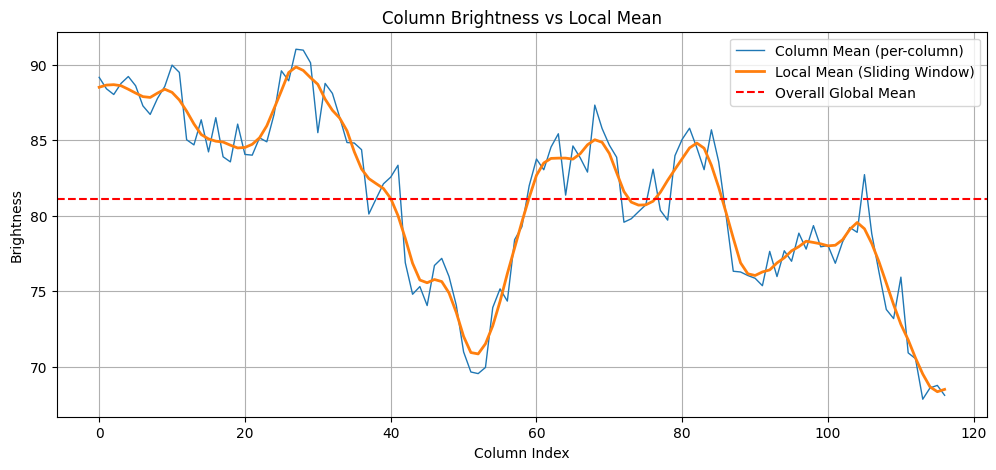

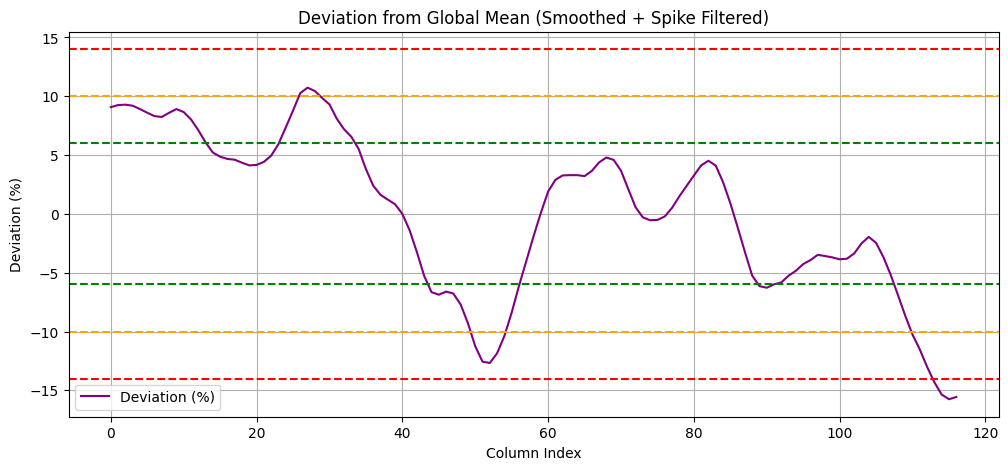

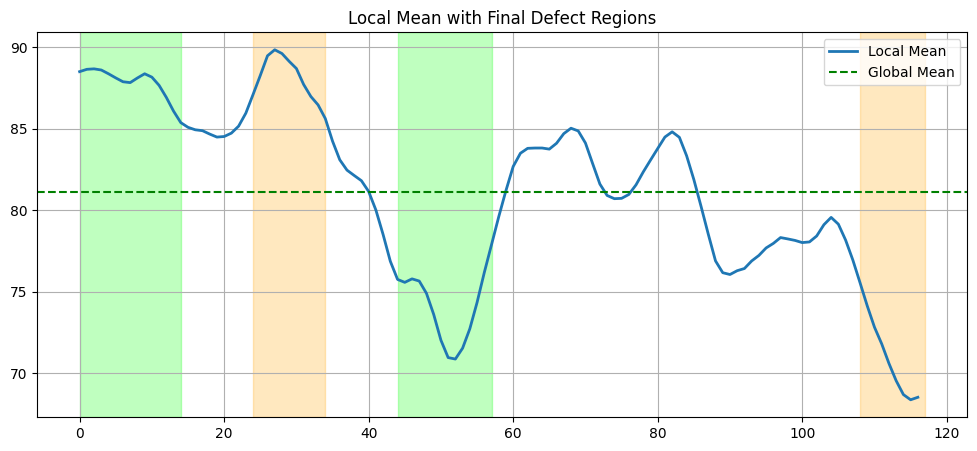

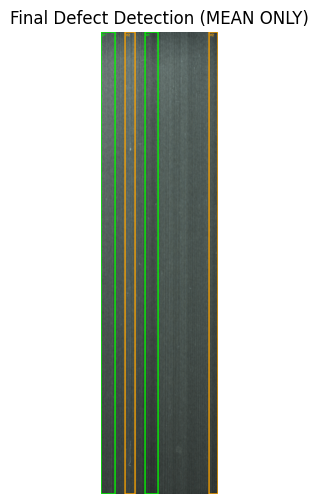

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# CONFIG
img_path = r"Evenness/Testing/10.png"
column_width = 10
window_size = 5
min_cols_for_defect = 6

# thresholds (% deviation from mean)
v1_threshold = 6
v2_threshold = 10
v3_threshold = 14

# bounding box colors (BGR)
colors = {
    "v1": (0, 255, 0),
    "v2": (0, 165, 255),
    "v3": (0, 0, 255)
}

# matplotlib colors
mpl_colors = {
    "v1": (0, 1, 0, 0.25),
    "v2": (1, 0.65, 0, 0.25),
    "v3": (1, 0, 0, 0.25)
}

# LOAD IMAGE
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {img_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

# COLUMN MEAN BRIGHTNESS
num_cols = w // column_width
column_means = np.array([
    np.mean(gray[:, i * column_width: min((i + 1) * column_width, w)])
    for i in range(num_cols)
])

# GLOBAL MEAN
global_mean = float(np.mean(gray))
print(f"Global Mean Brightness: {global_mean:.2f}")

# LOCAL MEAN + SMOOTHING
half = window_size // 2
local_means = np.array([
    np.mean(column_means[max(0, i - half): min(num_cols, i + half + 1)])
    for i in range(num_cols)
])

local_means = savgol_filter(local_means, window_length=5, polyorder=2)

# DEVIATION (% FROM GLOBAL MEAN)
eps = 1e-8
deviation = ((local_means - global_mean) / (global_mean + eps)) * 100

# Evenness CLASSIFICATION
def classify_column(dev):
    ad = abs(dev)
    if ad >= v3_threshold:
        return "v3"
    elif ad >= v2_threshold:
        return "v2"
    elif ad >= v1_threshold:
        return "v1"
    else:
        return None

initial_classes = [classify_column(d) for d in deviation]

# REGION EXTRACTION
def get_regions(class_list):
    regions = []
    start = None
    current = None

    for i, c in enumerate(class_list):
        if c != current:
            if current is not None:
                regions.append((start, i - 1, current))
            start = i if c is not None else None
            current = c

    if current is not None:
        regions.append((start, len(class_list) - 1, current))

    return regions

regions = get_regions(initial_classes)

# SPIKE FILTERING 
filtered_classes = initial_classes.copy()

for start, end, cls in regions:
    length = end - start + 1

    if length < min_cols_for_defect:
        left = filtered_classes[start - 1] if start > 0 else None
        right = filtered_classes[end + 1] if end + 1 < num_cols else None
        replacement = left if left is not None else right

        for i in range(start, end + 1):
            filtered_classes[i] = replacement

# FINAL REGIONS AFTER SPIKE FILTERING
final_regions = [
    r for r in get_regions(filtered_classes)
    if (r[1] - r[0] + 1) >= min_cols_for_defect
]

# MERGE ADJACENT REGIONS IF GAP < min_cols_for_defect
merged_regions = []
i = 0

while i < len(final_regions):
    start1, end1, cls1 = final_regions[i]
    width1 = end1 - start1 + 1
    j = i + 1

    while j < len(final_regions):
        start2, end2, cls2 = final_regions[j]
        width2 = end2 - start2 + 1
        gap = start2 - end1 - 1

        if gap < min_cols_for_defect:
            chosen_class = cls1 if width1 >= width2 else cls2
            end1 = end2
            cls1 = chosen_class
            width1 = end1 - start1 + 1
            j += 1
        else:
            break

    merged_regions.append((start1, end1, cls1))
    i = j

final_regions = merged_regions

# DRAW BOUNDING BOXES
output_img = img.copy()
class_counts = {"v1": 0, "v2": 0, "v3": 0}

for start, end, cls in final_regions:
    if cls is None:
        continue

    x1 = start * column_width
    x2 = min((end + 1) * column_width, w - 1)

    cv2.rectangle(output_img, (x1, 0), (x2, h - 1), colors[cls], 12)
    cv2.putText(output_img, cls.upper(), (x1 + 10, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, colors[cls], 3)

    class_counts[cls] += 1

cv2.imwrite("detected_defects_MEAN.jpg", output_img)

# RESULTS
print("\n=== DEFECT SUMMARY (MEAN ONLY) ===")
for k, v in class_counts.items():
    print(f"{k.upper()}: {v}")

# PLOTS
# Plot 1: Column brightness with Local Mean and Global Mean
plt.figure(figsize=(12, 5))
plt.plot(column_means, label='Column Mean (per-column)', linewidth=1)
plt.plot(local_means, label='Local Mean (Sliding Window)', linewidth=2)
plt.axhline(y=global_mean, color='red', linestyle='--', label='Overall Global Mean')
plt.title("Column Brightness vs Local Mean")
plt.xlabel("Column Index")
plt.ylabel("Brightness")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Local Mean vs Global Mean brightness with defect classification overlay
plt.figure(figsize=(12, 5))
plt.plot(deviation, label="Deviation (%)", color="purple")
plt.axhline(v1_threshold, color="green", linestyle="--")
plt.axhline(-v1_threshold, color="green", linestyle="--")
plt.axhline(v2_threshold, color="orange", linestyle="--")
plt.axhline(-v2_threshold, color="orange", linestyle="--")
plt.axhline(v3_threshold, color="red", linestyle="--")
plt.axhline(-v3_threshold, color="red", linestyle="--")
plt.title("Deviation from Global Mean (Smoothed + Spike Filtered)")
plt.xlabel("Column Index")
plt.ylabel("Deviation (%)")
plt.grid(True)
plt.legend()
plt.show()

# plot 3: Local Mean with Final Defect Regions
plt.figure(figsize=(12, 5))
plt.plot(local_means, label="Local Mean", linewidth=2)
plt.axhline(global_mean, color="green", linestyle="--", label="Global Mean")

for s, e, cls in final_regions:
    plt.axvspan(s, e + 1, color=mpl_colors[cls])

plt.legend()
plt.grid(True)
plt.title("Local Mean with Final Defect Regions")
plt.show()

# final Result with Bounding Box
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title("Final Defect Detection (MEAN ONLY)")
plt.axis("off")
plt.show()


## Batch Processing Using Mean PipeLine

In [2]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

folder_path = r"Evenness/Testing"
output_csv = "defect_summary.csv"
output_image_dir = "output_images"

column_width = 10
window_size = 5
min_cols_for_defect = 6

v1_threshold = 6
v2_threshold = 10
v3_threshold = 14

os.makedirs(output_image_dir, exist_ok=True)

colors = {
    "v1": (0, 255, 0),
    "v2": (0, 165, 255),
    "v3": (0, 0, 255)
}

def classify(dev):
    ad = abs(dev)
    if ad >= v3_threshold:
        return "v3"
    elif ad >= v2_threshold:
        return "v2"
    elif ad >= v1_threshold:
        return "v1"
    else:
        return None


def get_regions(class_list):
    regions = []
    start = None
    current = None

    for i, c in enumerate(class_list):
        if c != current:
            if current is not None:
                regions.append((start, i - 1, current))
            start = i if c is not None else None
            current = c

    if current is not None:
        regions.append((start, len(class_list) - 1, current))

    return regions


# PROCESS SINGLE IMAGE
def process_image(img_path):
    img_name = os.path.basename(img_path)
    img = cv2.imread(img_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    num_cols = w // column_width
    if num_cols <= 0:
        return None

    # ---- Column means
    column_means = np.array([
        np.mean(gray[:, i * column_width: min((i + 1) * column_width, w)])
        for i in range(num_cols)
    ])

    global_mean = float(np.mean(gray))

    # ---- Local means + smoothing
    half = window_size // 2
    local_means = np.array([
        np.mean(column_means[max(0, i - half): min(num_cols, i + half + 1)])
        for i in range(num_cols)
    ])
    local_means = savgol_filter(local_means, 5, 2)

    # ---- Deviation
    deviation = ((local_means - global_mean) / (global_mean + 1e-8)) * 100

    # ---- Initial classification
    initial_classes = [classify(d) for d in deviation]

    # SOLUTION-2: SPIKE FILTERING(Sandwich Case)
    regions = get_regions(initial_classes)
    filtered_classes = initial_classes.copy()

    for start, end, cls in regions:
        length = end - start + 1
        if length < min_cols_for_defect:
            left = filtered_classes[start - 1] if start > 0 else None
            right = filtered_classes[end + 1] if end + 1 < num_cols else None
            replacement = left if left is not None else right
            for i in range(start, end + 1):
                filtered_classes[i] = replacement

    # FINAL REGIONS AFTER SPIKE FILTERING
    final_regions = [
        r for r in get_regions(filtered_classes)
        if (r[1] - r[0] + 1) >= min_cols_for_defect
    ]

    # MERGE ADJACENT REGIONS IF GAP < min_cols_for_defect
    merged_regions = []
    i = 0

    while i < len(final_regions):
        start1, end1, cls1 = final_regions[i]
        width1 = end1 - start1 + 1
        j = i + 1

        while j < len(final_regions):
            start2, end2, cls2 = final_regions[j]
            width2 = end2 - start2 + 1
            gap = start2 - end1 - 1

            if gap < min_cols_for_defect:
                chosen_class = cls1 if width1 >= width2 else cls2
                end1 = end2
                cls1 = chosen_class
                width1 = end1 - start1 + 1
                j += 1
            else:
                break

        merged_regions.append((start1, end1, cls1))
        i = j

    # DRAW Bounding box
    output_img = img.copy()
    counts = {"v1": 0, "v2": 0, "v3": 0}

    for s, e, cls in merged_regions:
        if cls is None:
            continue
        x1 = s * column_width
        x2 = min((e + 1) * column_width, w - 1)
        cv2.rectangle(output_img, (x1, 0), (x2, h - 1), colors[cls], 12)
        cv2.putText(output_img, cls.upper(), (x1 + 10, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, colors[cls], 3)
        counts[cls] += 1

    out_img_path = os.path.join(
        output_image_dir, f"{os.path.splitext(img_name)[0]}_MEAN.jpg"
    )
    cv2.imwrite(out_img_path, output_img)

    return {
        "Image": img_name,
        "Mean_Brightness": global_mean,
        "v1_Count": counts["v1"],
        "v2_Count": counts["v2"],
        "v3_Count": counts["v3"],
        "Total_Defects": sum(counts.values())
    }


# MAIN
rows = []
image_paths = sorted(
    p for p in glob.glob(os.path.join(folder_path, "*"))
    if p.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
)[:10]

for path in image_paths:
    result = process_image(path)
    if result:
        rows.append(result)

pd.DataFrame(rows).to_csv(output_csv, index=False)

print(f"Processed {len(rows)} images")
print(f"CSV saved to: {output_csv}")
print(f"Annotated images saved to: {output_image_dir}")


Processed 10 images
CSV saved to: defect_summary.csv
Annotated images saved to: output_images
